<a href="https://colab.research.google.com/github/reubyTuesday/Math509RealEstate/blob/main/Boston_Dataset_MATH509_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# MATH 509 Project - Boston Dataset - MCMC Regression Approach.
%pylab inline
%config InlineBackend.figure_format = 'retina'
from ipywidgets import interact
import scipy.stats as stats
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_openml


Populating the interactive namespace from numpy and matplotlib


# Load data from the source

In [ ]:
# Define the path to the dataset
path_to_data = 'https://drive.google.com/uc?id=1hWB66jk3g37_Qq53UHx_lDG2iIQCmNkQ'

# Read the dataset without assuming a header
data = pd.read_csv(path_to_data, delim_whitespace=True, header=None)

# Define column names (ensure they match the dataset)
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
                'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# Assign column names to the DataFrame
data.columns = column_names

# Delete the 'B' column
data = data.drop('B', axis=1)

print(data.describe())
# Display the entire dataset
# print(data)

<ipython-input-3-00fa56bd2a0a>:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path_to_data, delim_whitespace=True, header=None)


             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO       LSTAT  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534   12.653063   
std     28.148861    2.1057

In [ ]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


# Applying mean imputation to polish the outliers

In [ ]:
# Compute 95th percentile threshold
threshold1 = data['CRIM'].quantile(0.95)

# Replace values greater than the 95th percentile with the threshold value
data.loc[data['CRIM'] > threshold1, 'CRIM'] = data.loc[data['CRIM'] <=threshold1, 'CRIM'].mean()

# Compute 95th percentile threshold
threshold2 = data['ZN'].quantile(0.95)

# Replace values greater than the 95th percentile with the threshold value
data.loc[data['ZN'] > threshold2, 'ZN'] = data.loc[data['ZN'] <=threshold2, 'ZN'].mean()

# Compute 95th percentile threshold
threshold3 = data['MEDV'].quantile(0.95)

# Replace values greater than the 95th percentile with the threshold value
data.loc[data['MEDV'] > threshold3, 'MEDV'] = data.loc[data['MEDV'] <=threshold3, 'MEDV'].mean()

display(data.describe())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,2.092157,9.115854,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,21.128750
std,3.553630,19.113102,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,6.917394
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.128750
75%,2.092157,9.115854,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,24.100000
max,15.575700,80.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,43.100000


# Get rid of 'RAD' variable, because it is highly correlated with another variable 'TAX'.

In [ ]:
# Delete the 'RAD' column
data = data.drop('RAD', axis=1)

# Splitting data into training set and validation set

In [ ]:
# Import the necessary function
from sklearn.model_selection import train_test_split

# Set the random seed for reproducibility
np.random.seed(123)

# Define X and y
X = data.drop('MEDV', axis=1)  # Features (all columns except 'MEDV')
y = data['MEDV']  # Target variable

# Split the dataset into train and validation sets
x_train, x_valid, y_train, y_valid = train_test_split(X, y, train_size=406, random_state=123)

# Check the shapes of the train and validation sets
print(x_train.shape)
print(x_valid.shape)

(406, 11)
(100, 11)


# MCMC Regression

In [ ]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
from sklearn.preprocessing import StandardScaler

# Standardizing only continuous predictors (excluding 'CHAS')
continuous_features = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'LSTAT']
scaler = StandardScaler()
x_train_standardized = pd.DataFrame(scaler.fit_transform(x_train[continuous_features]),
                                    columns=continuous_features)

# Add 'CHAS' back (unchanged, as it is categorical)
x_train_standardized['CHAS'] = x_train['CHAS'].values  # Keep it binary (0 or 1)

# MCMC Model
with pm.Model() as model1:
    sigma = pm.Exponential('sigma', 1)
    alpha = pm.Normal('alpha', mu=20, sigma=3)

    # Continuous predictors
    beta = {var: pm.Normal(f'beta_{var}', mu=0, sigma=1.5) for var in continuous_features}

    # Dummy variable (CHAS)
    beta_CHAS = pm.Normal('beta_CHAS', mu=0, sigma=1)

    # Compute linear predictor
    _mu = alpha
    for var in continuous_features:
        _mu += beta[var] * x_train_standardized[var]

    # Include CHAS separately
    _mu += beta_CHAS * x_train_standardized['CHAS']

    mu = pm.Deterministic('mu', _mu)
    y_new = pm.Normal('MEDV', mu=mu, sigma=sigma, observed=y_train)

    _model1_samples = pm.sample(1000, tune=1000, chains=2, return_inferencedata=True)

# Extract posterior samples
posterior_samples = az.extract(_model1_samples)

# Extract beta coefficients
beta_coeffs = continuous_features + ['CHAS']  # Include CHAS
beta_samples = np.stack([posterior_samples[f'beta_{beta}'].values for beta in beta_coeffs], axis=-1)

# Extract alpha samples
alpha_samples_np = posterior_samples["alpha"].values.reshape(-1, 1)

# Compute predictions on TRAINING set
x_train_np = x_train_standardized.values  # Already standardized (except CHAS)
y_pred_train_samples = alpha_samples_np + np.dot(beta_samples, x_train_np.T)
y_pred_train_mean = y_pred_train_samples.mean(axis=0)  # Posterior mean



Output()

In [ ]:
varnames = ['beta_CRIM', 'beta_ZN', 'beta_INDUS', 'beta_CHAS','beta_NOX', 'beta_RM', 'beta_AGE', 'beta_DIS', 'beta_TAX','beta_PTRATIO', 'beta_LSTAT', 'sigma', 'alpha']
display(pm.summary(_model1_samples))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,20.908,0.214,20.504,21.303,0.004,0.005,2428.0,1467.0,1.0
beta_AGE,-0.135,0.350,-0.805,0.459,0.008,0.008,1987.0,1329.0,1.0
beta_CHAS,0.639,0.713,-0.630,2.021,0.016,0.020,1983.0,986.0,1.0
beta_CRIM,0.104,0.331,-0.492,0.742,0.007,0.007,2067.0,1312.0,1.0
beta_DIS,-1.026,0.393,-1.706,-0.232,0.008,0.009,2305.0,1414.0,1.0
...,...,...,...,...,...,...,...,...,...
mu[402],15.980,0.497,15.089,16.906,0.010,0.011,2547.0,1685.0,1.0
mu[403],23.404,0.437,22.532,24.190,0.009,0.010,2455.0,1471.0,1.0
mu[404],12.393,0.506,11.454,13.334,0.011,0.009,2003.0,1875.0,1.0
mu[405],17.734,1.385,15.094,20.261,0.031,0.034,2055.0,1351.0,1.0


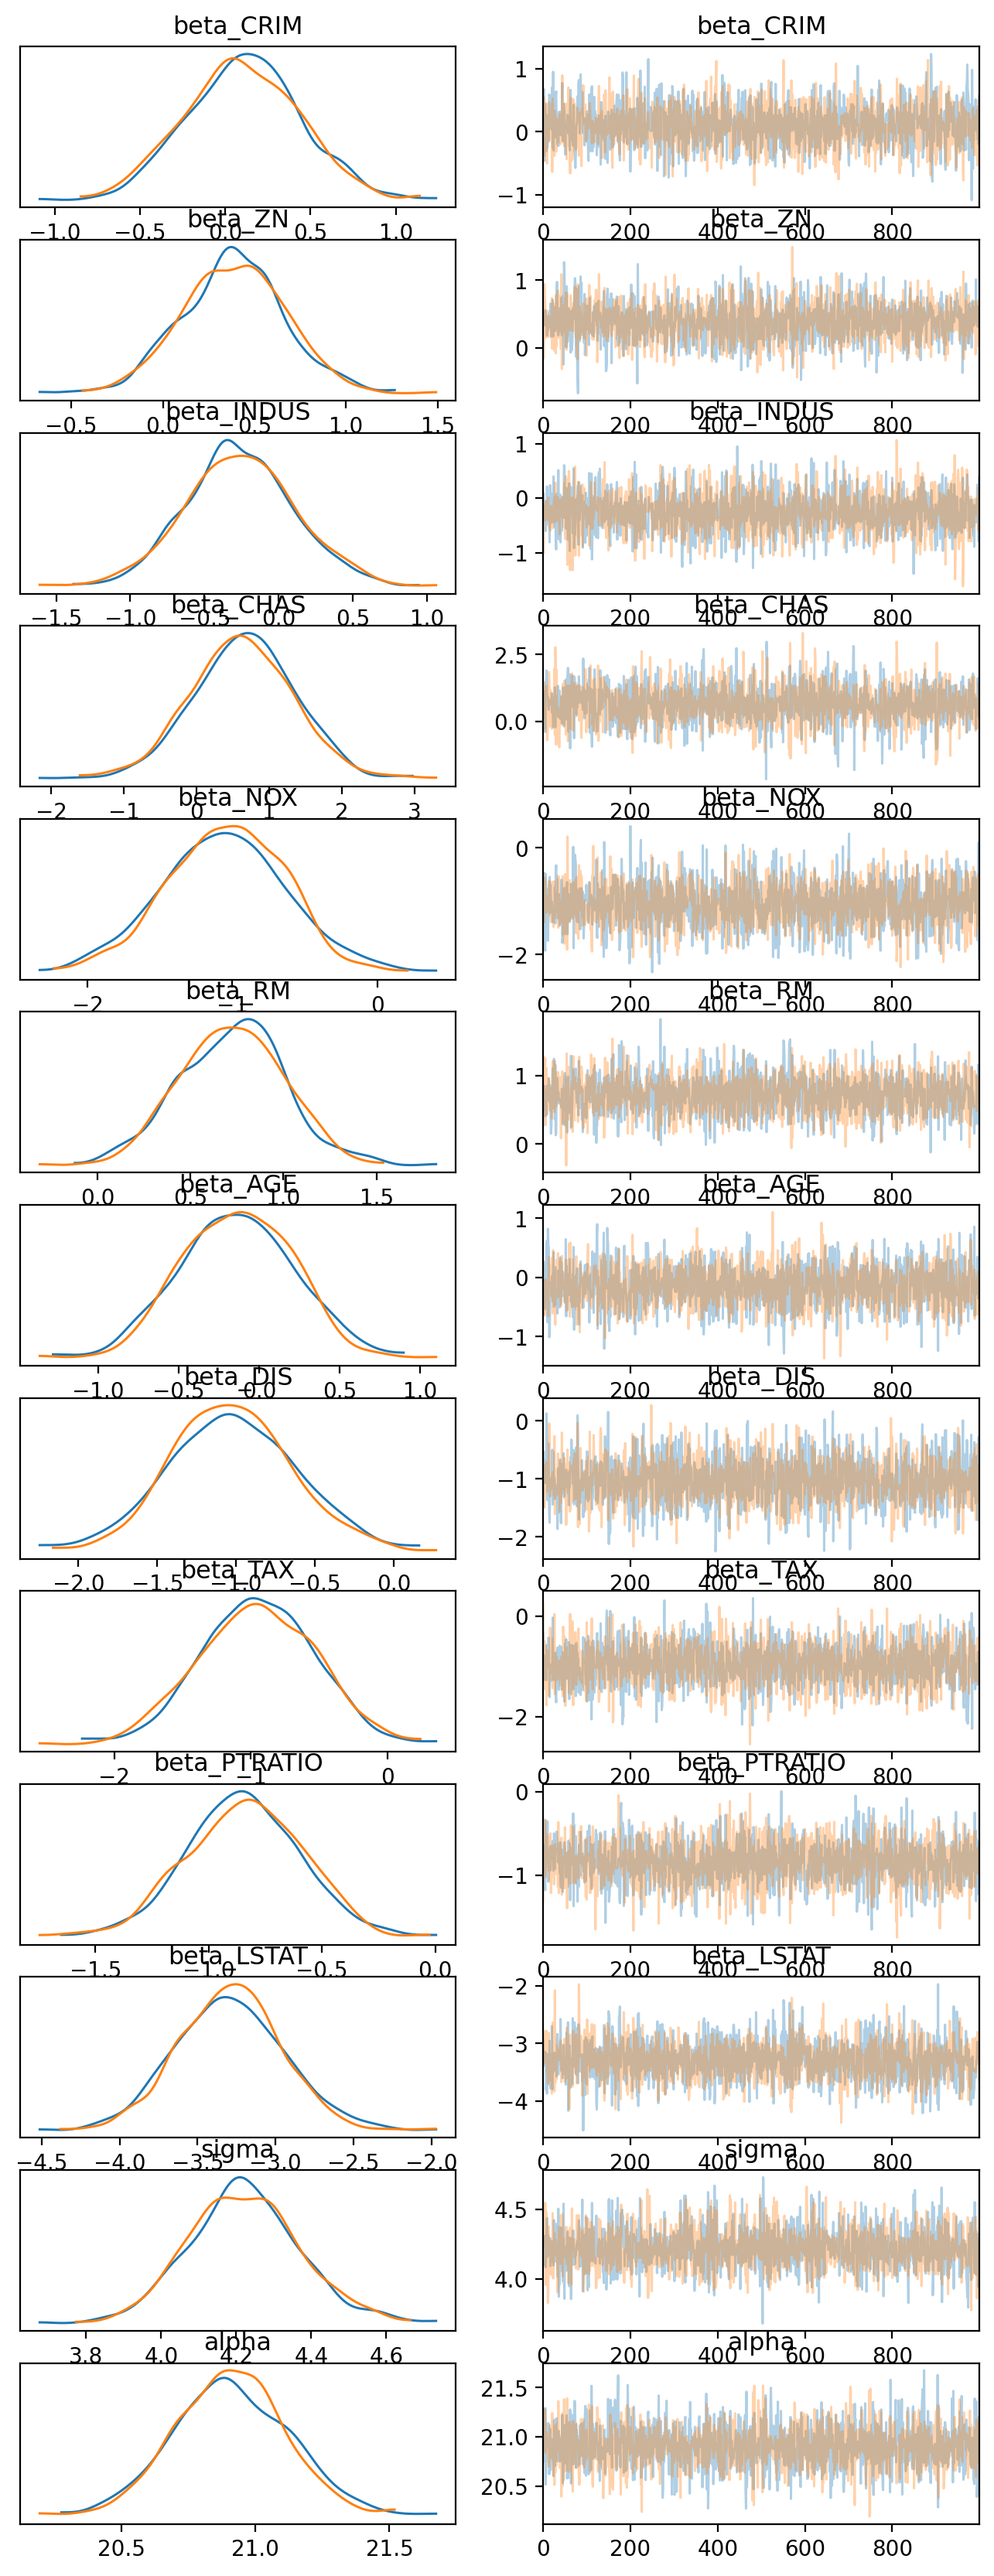

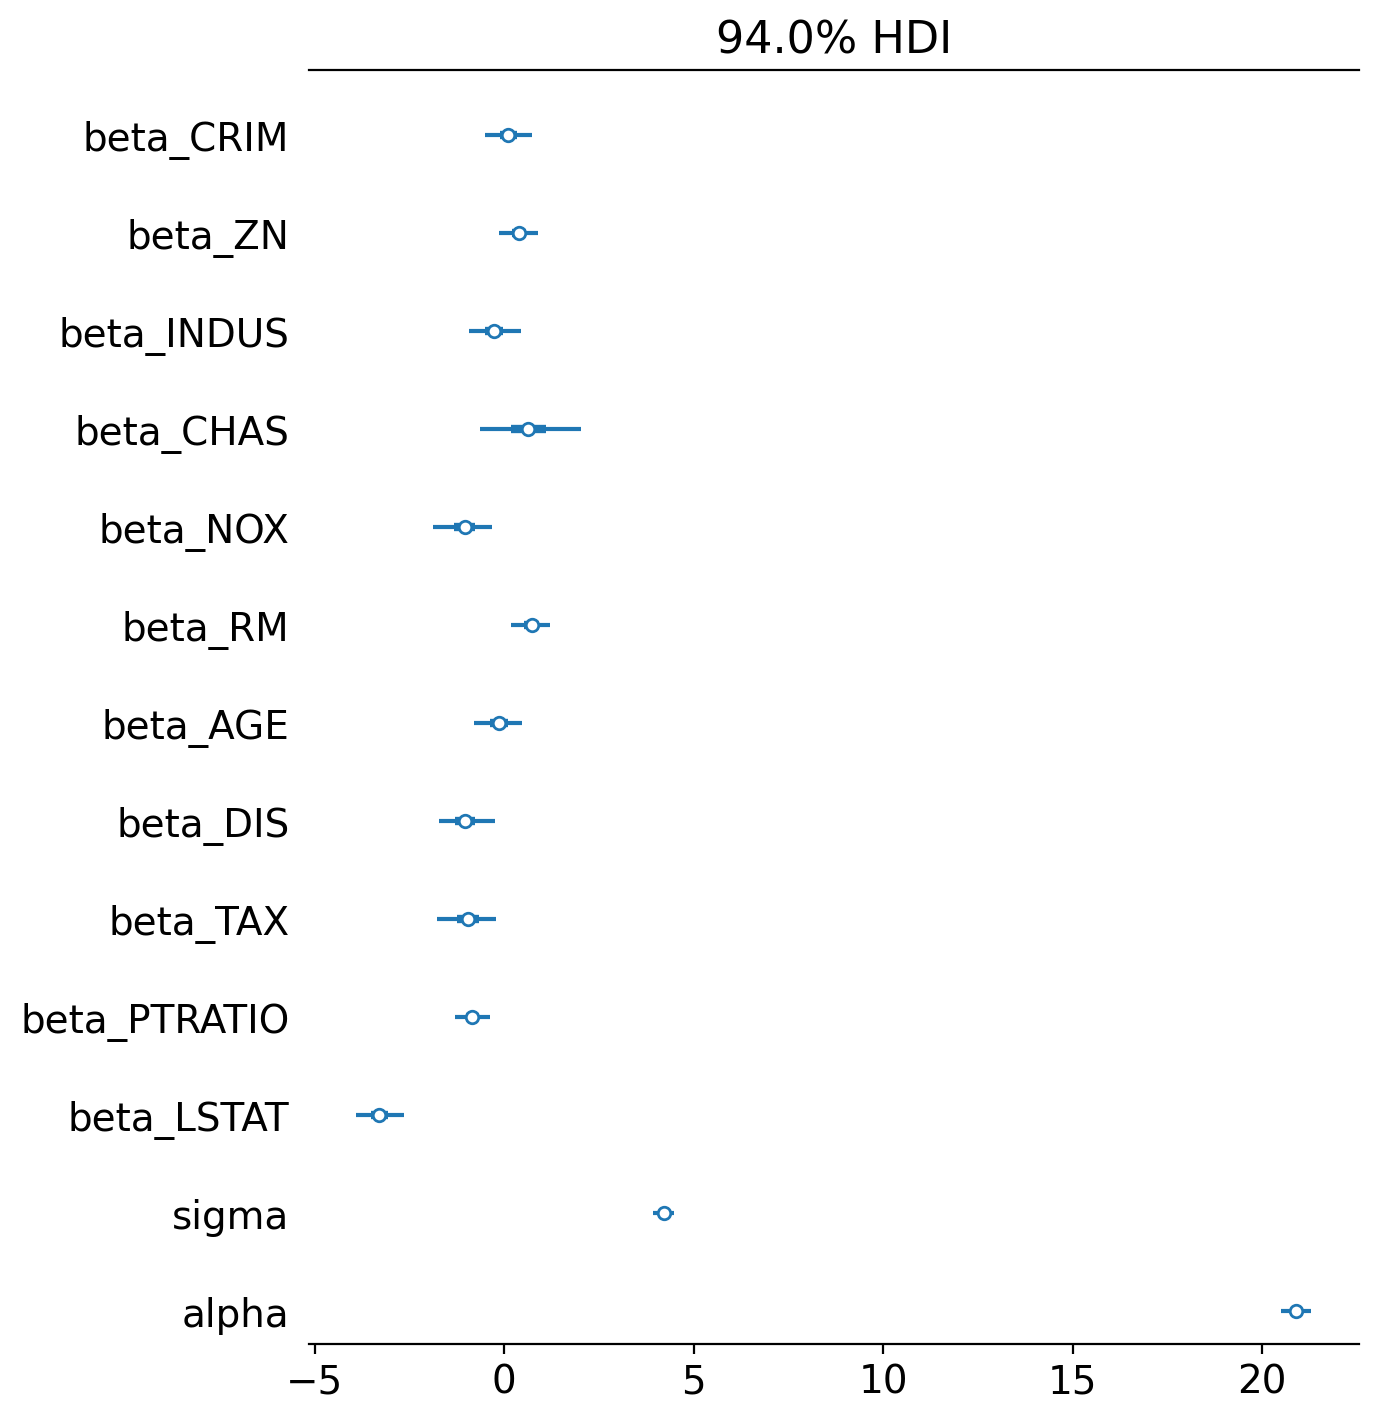

In [ ]:
# Set figure size for better readability
figsize = (7, 2 + 0.4 * len(varnames))  # Dynamic height based on variable count

# Trace plot (optional, if needed)
az.plot_trace(_model1_samples, var_names=varnames, compact=False, figsize=(8, 1.6 * len(varnames)))

# Improved Forest Plot
az.plot_forest(
    _model1_samples,
    var_names=varnames,
    combined=True,
    figsize=figsize,
    hdi_prob=0.94,  # Explicitly setting HDI
    ridgeplot_alpha=0.7,  # Slight transparency for better visualization
    markersize=6  # Larger points
)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()


# Compute MSE, $R^2$, Adjusted $R^2$, AIC and BIC for MCMC Regression:

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Standardize x_valid using the same scaler fitted on x_train
scaler = StandardScaler()
scaler.fit(x_train)  # Already fitted on training data
x_valid_standardized = pd.DataFrame(scaler.transform(x_valid), columns=x_valid.columns)

# Extract posterior samples (already done in your code)
posterior_samples = az.extract(_model1_samples)
alpha_mean = posterior_samples["alpha"].mean().item()
sigma_mean = posterior_samples["sigma"].mean().item()

# Beta coefficients list
beta_coeffs = ['beta_CRIM', 'beta_ZN', 'beta_INDUS', 'beta_CHAS','beta_NOX', 'beta_RM', 'beta_AGE', 'beta_DIS', 'beta_TAX','beta_PTRATIO', 'beta_LSTAT']

# Stack beta samples into a single NumPy array
beta_samples = np.stack([posterior_samples[beta].values for beta in beta_coeffs], axis=-1)

# Extract alpha (intercept) samples and reshape for broadcasting
alpha_samples_np = posterior_samples["alpha"].values.reshape(-1, 1)

# Convert x_valid_standardized to NumPy array
x_valid_np = x_valid_standardized.values

# Compute posterior predictive samples for validation set
y_pred_mcmc = alpha_samples_np + np.dot(beta_samples, x_valid_np.T)

# Compute the mean prediction across posterior samples
y_pred_valid_mean = y_pred_mcmc.mean(axis=0)

# Step 1: Compute Total Sum of Squares (TSS) for y_valid
y_valid_mean = np.mean(y_valid)
tss_valid = np.sum((y_valid - y_valid_mean) ** 2)

# Step 2: Compute Residual Sum of Squares (RSS) for y_valid
rss_valid = np.sum((y_valid - y_pred_valid_mean) ** 2)

# Step 3: Compute R² for validation set
r2_valid = 1 - (rss_valid / tss_valid)

# Step 4: (Optional) Compute MSE for consistency check
mse_valid_mcmc = mean_squared_error(y_valid, y_pred_valid_mean)

# Calculating Adjusted R^2

# Calculate number of observations (n) and number of predictors (k)
n_mcmc = len(y_train)  # Number of data points in the training set
p_mcmc = x_train.shape[1]  # Number of predictors (features)

# Calculate Adjusted R^2
adjusted_r2_valid_mcmc = 1 - ((1 - r2_valid) * (n_mcmc - 1) / (n_mcmc - p_mcmc - 1))

# Print results
print(f"Validation TSS: {tss_valid:.4f}")
print(f"Validation RSS: {rss_valid:.4f}")
print(f"Validation R^2: {r2_valid:.4f}")
print(f"Validation adjusted R^2: {adjusted_r2_valid_mcmc:.4f}")
print(f"Validation MSE: {mse_valid_mcmc:.4f}")

# --------------------------------- AIC & BIC -------------------

# Compute log-likelihood
log_likelihood_mcmc = stats.norm.logpdf(y_valid, loc=y_pred_valid_mean, scale=sigma_mean)
total_log_likelihood_mcmc = np.sum(log_likelihood_mcmc)

# Number of estimated parameters
k_mcmc = len(beta_coeffs) + 2  # Number of betas + alpha + sigma

# Number of observations
n_mcmc = len(y_valid)

# Compute AIC and BIC
AIC_mcmc = 2 * k_mcmc - 2 * total_log_likelihood_mcmc
BIC_mcmc = k_mcmc * np.log(n_mcmc) - 2 * total_log_likelihood_mcmc

# Print results
print("AIC (MCMC):", AIC_mcmc)
print("BIC (MCMC):", BIC_mcmc)

Validation TSS: 5074.5639
Validation RSS: 2025.6344
Validation R^2: 0.6008
Validation adjusted R^2: 0.5897
Validation MSE: 20.2563
AIC (MCMC): 611.4938770807349
BIC (MCMC): 645.3610894985801


# Result Analysis:

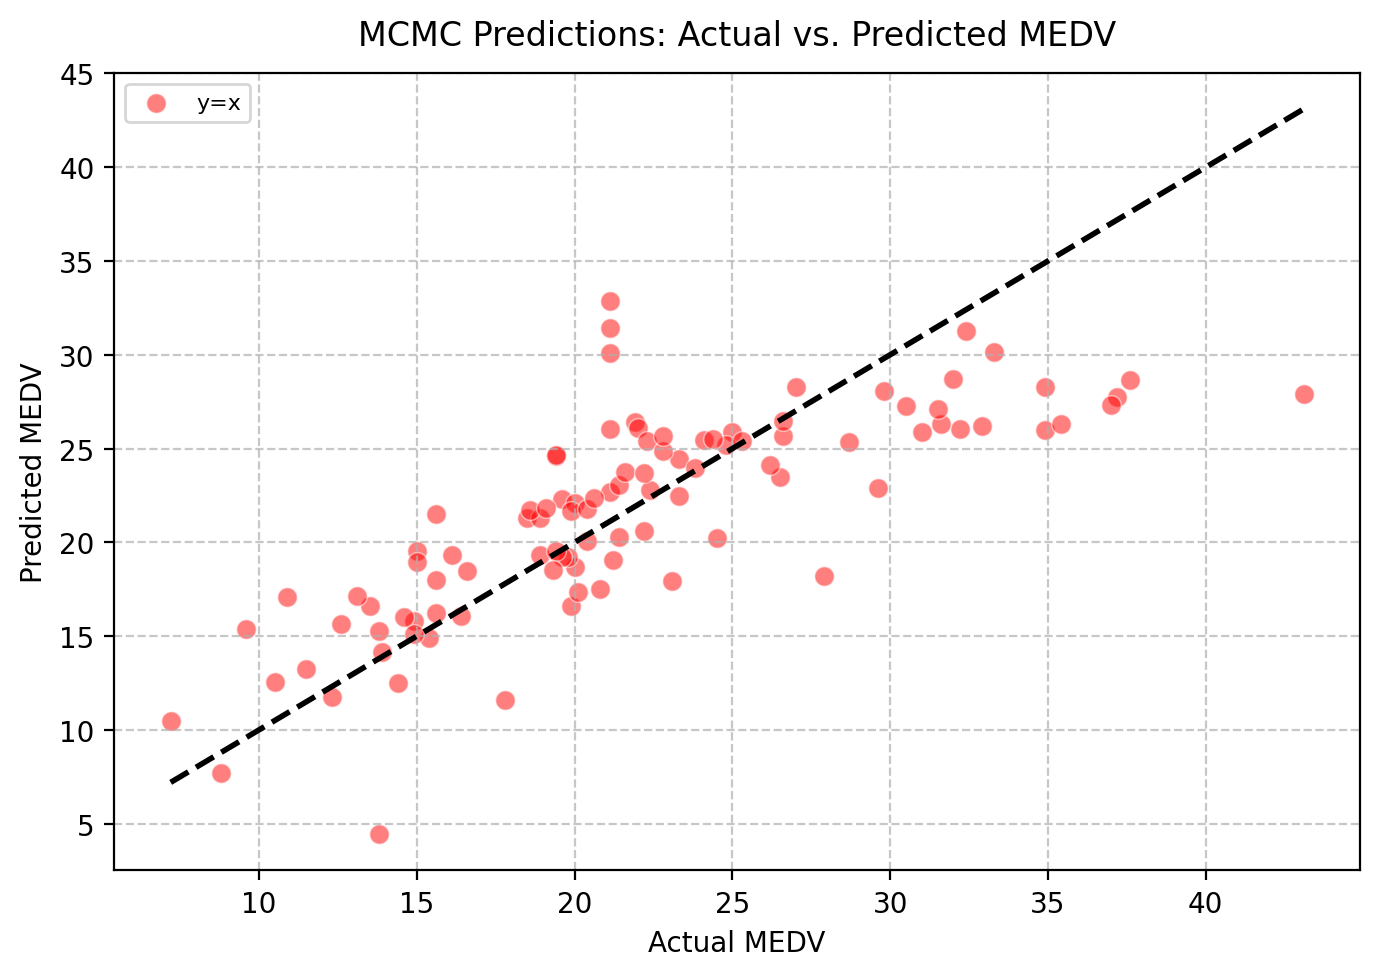

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)

# MCMC Predictions
posterior_samples = az.extract(_model1_samples)

# Beta coefficients list
beta_coeffs = ['beta_CRIM', 'beta_ZN', 'beta_INDUS', 'beta_CHAS',
               'beta_NOX', 'beta_RM', 'beta_AGE', 'beta_DIS',
               'beta_TAX', 'beta_PTRATIO', 'beta_LSTAT']

beta_samples = np.stack([posterior_samples[beta].values for beta in beta_coeffs], axis=-1)
alpha_samples_np = posterior_samples["alpha"].values.reshape(-1, 1)

x_valid_np = scaler.transform(x_valid)  # Standardized validation data
y_pred_samples = alpha_samples_np + np.dot(beta_samples, x_valid_np.T)
y_pred_mcmc = y_pred_samples.mean(axis=0)  # Posterior mean predictions

# Create a single plot
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))

# Scatter plot for MCMC predictions
sns.scatterplot(x=y_valid, y=y_pred_mcmc, color='red', alpha=0.5, s=50, ax=ax1)

# Reference line y=x
ax1.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()],
         'k--', lw=2, label='y=x')

# Labels and formatting
ax1.set_title("MCMC Predictions: Actual vs. Predicted MEDV", fontsize=12, pad=10)
ax1.set_xlabel("Actual MEDV", fontsize=10)
ax1.set_ylabel("Predicted MEDV", fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(['y=x'], loc='best', fontsize=8)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()
